<a href="https://colab.research.google.com/github/suvarshinigandham/FMML_Project_and_Labs/blob/main/AIML_Training_Program_Module_3_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Student Training Program on AIML**
# Project : Data Visualization, Choosing K-value and Appreciating Feature Scaling and Standardization

---

## Binary Classification Task: Diabetes Dataset

We'll be using ML techniques learnt uptil now to predict whether a Pima Indian Woman has diabetes or not, based on information about the patient such as blood pressure, body mass index (BMI), age, etc.

**Dataset Source:** [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)


# Introduction

Scientists carried out a study to investigate the significance of health-related predictors of diabetes in **Pima Indian Women**. The study population was females (21 years and above) of Pima Indian heritage.

The purpose of the study was to find out the factors that are associated with the presence of diabetes in Pima Indians.

To find out the reason behind this, we have to first analyze the relationship between different features, such as the number of times a woman was pregnant, their BMI, prevalence of diabetes, etc.

## Exploratory Data Analysis (EDA) and Statistical Analysis

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

## Load the Dataset

Upload the diabetes.csv file that has been provided to you.

In [ ]:
# Upload the diabetes data CSV file
from google.colab import files
uploaded = files.upload()

In [4]:
# Load the dataset
diabetes_data = pd.read_csv('diabetes.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'diabetes.csv'

## Dataset Overview

In [ ]:
# Display the first few rows
diabetes_data.head()

In [ ]:
# Check dataset dimensions
print(f"Dataset shape: {diabetes_data.shape}")
print(f"Number of samples: {diabetes_data.shape[0]}")
print(f"Number of features: {diabetes_data.shape[1]}")

In [ ]:
# Dataset information
diabetes_data.info()

In [ ]:
# Check for missing values
print("Missing values per column:")
print(diabetes_data.isnull().sum())

## Statistical Summary

In [ ]:
# Descriptive statistics
diabetes_data.describe()

In [ ]:
# Check the target variable distribution
print("Outcome distribution:")
print(diabetes_data['Outcome'].value_counts())
print(f"\nPercentage of diabetic cases: {diabetes_data['Outcome'].mean()*100:.2f}%")

## Data Visualization

In [ ]:
# Visualize the target variable distribution
plt.figure(figsize=(8,6))
sns.countplot(x='Outcome', data=diabetes_data, palette='viridis')
plt.title('Distribution of Diabetes Outcome', fontsize=14)
plt.xlabel('Outcome (0: No Diabetes, 1: Diabetes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

In [ ]:
# Distribution of all features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(diabetes_data.columns):
    sns.histplot(diabetes_data[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.show()

## TASK-1: Correlation Analysis

Compute the correlation matrix and visualize it using a heatmap to understand the relationships between different features.

In [ ]:
# Calculate correlation matrix
correlation_matrix = diabetes_data.corr()

# Visualize with heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.show()

## TASK-2: Comparative Box Plots

Create box plots to compare the distribution of each feature for diabetic vs non-diabetic patients.

In [ ]:
# Box plots for all features grouped by Outcome
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

feature_cols = diabetes_data.columns[:-1]  # All columns except Outcome

for i, col in enumerate(feature_cols):
    sns.boxplot(x='Outcome', y=col, data=diabetes_data, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Diabetes Outcome', fontsize=12)
    axes[i].set_xlabel('Outcome (0: No, 1: Yes)', fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)

# Hide the last subplot if not needed
axes[-1].axis('off')

plt.tight_layout()
plt.show()

## TASK-3: Pairplot Analysis

Create a pairplot to visualize the pairwise relationships between features, colored by the Outcome variable.

In [ ]:
# Select a subset of features for clearer visualization
selected_features = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']
sns.pairplot(diabetes_data[selected_features], hue='Outcome', palette='husl', diag_kind='kde', height=2.5)
plt.suptitle('Pairplot of Selected Features', y=1.02, fontsize=16)
plt.show()

## K-Nearest Neighbors (KNN) Classification

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## TASK-4: Train-Test Split

Split the dataset into training (70%) and testing (30%) sets.

In [ ]:
# Prepare features and target
X = diabetes_data.drop('Outcome', axis=1)
y = diabetes_data['Outcome']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

## TASK-5: Build and Evaluate KNN Model

Train a KNN classifier with k=1 and evaluate its performance.

In [ ]:
# Train KNN with k=1
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred)*100:.2f}%")

## TASK-6: Finding the Optimal K Value

Test different values of K (from 1 to 40) and plot the error rate to find the optimal K value.

In [ ]:
# Store the original unscaled data for later comparison
unchanged_data = X.copy()

# Function to evaluate KNN performance across different K values
def plot_KNN_error_rate(xdata, ydata):
    error_rate = []
    test_scores = []
    train_scores = []

    X_train, X_test, y_train, y_test = train_test_split(xdata, ydata, test_size=0.3, random_state=101)

    for i in range(1, 40):
        knn = KNeighborsClassifier(n_neighbors=i)
        knn.fit(X_train, y_train)
        pred_i = knn.predict(X_test)

        error_rate.append(np.mean(pred_i != y_test))
        train_scores.append(knn.score(X_train, y_train))
        test_scores.append(knn.score(X_test, y_test))

    # Plot error rate
    plt.figure(figsize=(12, 8))
    plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o',
             markerfacecolor='red', markersize=8)
    plt.title('Error Rate vs. K Value', fontsize=14)
    plt.xlabel('K', fontsize=12)
    plt.ylabel('Error Rate', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    # Find best K values
    max_train_score = max(train_scores)
    train_scores_ind = [i for i, v in enumerate(train_scores) if v == max_train_score]
    print(f'Max train score: {max_train_score*100:.2f}% at K = {[x+1 for x in train_scores_ind]}')

    max_test_score = max(test_scores)
    test_scores_ind = [i for i, v in enumerate(test_scores) if v == max_test_score]
    print(f'Max test score: {max_test_score*100:.2f}% at K = {[x+1 for x in test_scores_ind]}')

    return test_scores

In [ ]:
# Evaluate on unscaled data
print("Performance on Unscaled Data:")
unchanged_test_scores = plot_KNN_error_rate(unchanged_data, diabetes_data['Outcome'])

## Standardize the Variables

Standardization (also called z-score normalization) is the process of putting different variables on the same scale. Standardization transforms your data such that the resulting distribution has a mean of 0 and a standard deviation of 1.

$$ Z = {X - \mu \over \sigma}$$

Where:
- Z is the standardized value
- X is the original value
- μ is the mean of the feature
- σ is the standard deviation of the feature

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on training data features
scaler.fit(diabetes_data.drop('Outcome', axis=1))

# Transform the features
scaled_data = scaler.transform(diabetes_data.drop('Outcome', axis=1))

In [ ]:
# Create a dataframe with scaled features
df_feat = pd.DataFrame(scaled_data, columns=diabetes_data.columns[:-1])
df_feat.head()

In [ ]:
# Verify standardization: mean should be ~0, std should be ~1
print("Mean of scaled features:")
print(df_feat.mean())
print("\nStandard deviation of scaled features:")
print(df_feat.std())

In [ ]:
# Evaluate on scaled data
print("Performance on Standardized Data:")
scaled_test_scores = plot_KNN_error_rate(scaled_data, diabetes_data['Outcome'])

## Comparing Accuracy Before and After Standardization

In [ ]:
# Compare performance
plt.figure(figsize=(14, 8))
plt.plot(range(1, 40), unchanged_test_scores, marker='o', label='Unscaled Data', linewidth=2)
plt.plot(range(1, 40), scaled_test_scores, marker='s', label='Standardized Data', linewidth=2)
plt.title('KNN Accuracy: Unscaled vs Standardized Data', fontsize=14)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Conclusion

From the data analysis we carried out, it seems that there is some form of an association between BMI, number of pregnancies, glucose levels, and the test results for diabetes.

As for the classification tasks, the standardized data yields much better results than the unscaled data over most of the K-values considered, thus indicating the importance of standardizing data in Machine Learning problems. This improvement occurs because:

1. KNN is distance-based and features with larger scales dominate the distance calculation
2. Standardization puts all features on equal footing
3. This leads to more balanced and accurate predictions

---
# DIY Challenges

Test your understanding by completing these three challenges. Solutions are not provided - work through them independently!

## Challenge 1: MinMax Scaling Comparison

**Objective:** Implement MinMax scaling and compare its performance with StandardScaler.

**Tasks:**
1. Import `MinMaxScaler` from sklearn.preprocessing
2. Apply MinMax scaling to the dataset (scales features to range [0, 1])
3. Use the `plot_KNN_error_rate()` function on the MinMax-scaled data
4. Create a comparison plot showing all three approaches: unscaled, standardized, and MinMax-scaled
5. Analyze which scaling method performs best and why

**Hint:** MinMaxScaler formula is: $X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$

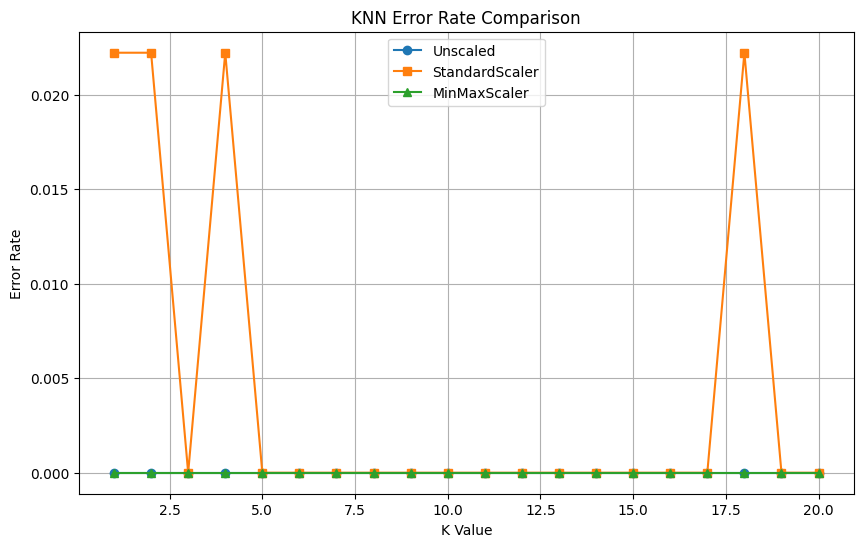

In [5]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Function to calculate error rates
def plot_KNN_error_rate(X_train, X_test, y_train, y_test, label):
    error_rate = []

    for k in range(1, 21):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)

        pred = knn.predict(X_test)

        error = np.mean(pred != y_test)
        error_rate.append(error)

    return error_rate

# 1. Unscaled Data
error_unscaled = plot_KNN_error_rate(
    X_train, X_test, y_train, y_test, "Unscaled"
)

# 2. Standard Scaled Data
standard_scaler = StandardScaler()

X_train_std = standard_scaler.fit_transform(X_train)
X_test_std = standard_scaler.transform(X_test)

error_standard = plot_KNN_error_rate(
    X_train_std, X_test_std, y_train, y_test, "StandardScaler"
)

# 3. MinMax Scaled Data
minmax_scaler = MinMaxScaler()

X_train_mm = minmax_scaler.fit_transform(X_train)
X_test_mm = minmax_scaler.transform(X_test)

error_minmax = plot_KNN_error_rate(
    X_train_mm, X_test_mm, y_train, y_test, "MinMaxScaler"
)

# Plot comparison
plt.figure(figsize=(10,6))

plt.plot(range(1,21), error_unscaled,
         marker='o', label='Unscaled')

plt.plot(range(1,21), error_standard,
         marker='s', label='StandardScaler')

plt.plot(range(1,21), error_minmax,
         marker='^', label='MinMaxScaler')

plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.title("KNN Error Rate Comparison")
plt.legend()
plt.grid(True)

plt.show()

## Challenge 2: K-Fold Cross-Validation Analysis

**Objective:** Implement K-Fold cross-validation to get more robust performance estimates.

**Tasks:**
1. Import `cross_val_score` from sklearn.model_selection
2. Implement 5-fold cross-validation for KNN with K values from 1 to 40
3. Compare cross-validation scores for:
   - Unscaled data
   - Standardized data
   - MinMax-scaled data (from Challenge 1)
4. Plot the mean cross-validation accuracy with standard deviation error bars
5. Determine the optimal K value for each scaling approach

**Bonus:** Calculate and display the standard deviation of cross-validation scores to understand model stability.

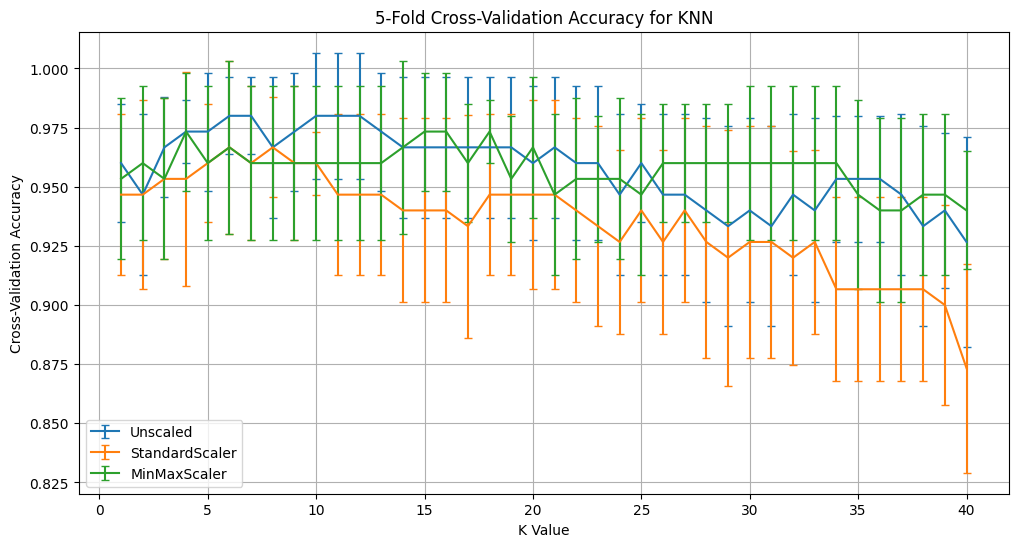

Optimal K Values:
-------------------
Unscaled Data: K = 6, Accuracy = 0.9800
StandardScaler: K = 6, Accuracy = 0.9667
MinMaxScaler: K = 4, Accuracy = 0.9733

Model Stability (Std Dev at Best K):
------------------------------------
Unscaled Std Dev: 0.0163
StandardScaler Std Dev: 0.0365
MinMaxScaler Std Dev: 0.0249


In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# Load dataset
data = load_iris()
X = data.data
y = data.target

# K range
k_values = range(1, 41)

# Lists to store results
mean_unscaled = []
std_unscaled = []

mean_standard = []
std_standard = []

mean_minmax = []
std_minmax = []

# Loop through K values
for k in k_values:

    # -----------------------------
    # 1. Unscaled Data
    # -----------------------------
    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X,
        y,
        cv=5,
        scoring='accuracy'
    )

    mean_unscaled.append(scores.mean())
    std_unscaled.append(scores.std())

    # -----------------------------
    # 2. StandardScaler + KNN
    # -----------------------------
    pipeline_std = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    scores_std = cross_val_score(
        pipeline_std,
        X,
        y,
        cv=5,
        scoring='accuracy'
    )

    mean_standard.append(scores_std.mean())
    std_standard.append(scores_std.std())

    # -----------------------------
    # 3. MinMaxScaler + KNN
    # -----------------------------
    pipeline_mm = Pipeline([
        ('scaler', MinMaxScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    scores_mm = cross_val_score(
        pipeline_mm,
        X,
        y,
        cv=5,
        scoring='accuracy'
    )

    mean_minmax.append(scores_mm.mean())
    std_minmax.append(scores_mm.std())

# ---------------------------------------------------
# Plot Mean Accuracy with Standard Deviation Errorbars
# ---------------------------------------------------

plt.figure(figsize=(12, 6))

plt.errorbar(
    k_values,
    mean_unscaled,
    yerr=std_unscaled,
    label='Unscaled',
    capsize=3
)

plt.errorbar(
    k_values,
    mean_standard,
    yerr=std_standard,
    label='StandardScaler',
    capsize=3
)

plt.errorbar(
    k_values,
    mean_minmax,
    yerr=std_minmax,
    label='MinMaxScaler',
    capsize=3
)

plt.xlabel("K Value")
plt.ylabel("Cross-Validation Accuracy")
plt.title("5-Fold Cross-Validation Accuracy for KNN")
plt.legend()
plt.grid(True)

plt.show()

# ---------------------------------------------------
# Find Optimal K Values
# ---------------------------------------------------

best_k_unscaled = np.argmax(mean_unscaled) + 1
best_k_standard = np.argmax(mean_standard) + 1
best_k_minmax = np.argmax(mean_minmax) + 1

print("Optimal K Values:")
print("-------------------")

print(f"Unscaled Data: K = {best_k_unscaled}, "
      f"Accuracy = {max(mean_unscaled):.4f}")

print(f"StandardScaler: K = {best_k_standard}, "
      f"Accuracy = {max(mean_standard):.4f}")

print(f"MinMaxScaler: K = {best_k_minmax}, "
      f"Accuracy = {max(mean_minmax):.4f}")

# ---------------------------------------------------
# Bonus: Display Standard Deviations
# ---------------------------------------------------

print("\nModel Stability (Std Dev at Best K):")
print("------------------------------------")

print(f"Unscaled Std Dev: "
      f"{std_unscaled[best_k_unscaled-1]:.4f}")

print(f"StandardScaler Std Dev: "
      f"{std_standard[best_k_standard-1]:.4f}")

print(f"MinMaxScaler Std Dev: "
      f"{std_minmax[best_k_minmax-1]:.4f}")

## Challenge 3: Feature Selection and Performance Analysis

**Objective:** Investigate how feature selection impacts KNN performance.

**Tasks:**
1. Based on the correlation analysis from TASK-1, identify the top 4 features most correlated with 'Outcome'
2. Create a reduced dataset with only these 4 features
3. Apply standardization to this reduced feature set
4. Train KNN models (K from 1 to 40) on both:
   - Full feature set (standardized)
   - Reduced feature set (standardized)
5. Create a comparison plot showing:
   - Accuracy vs K for full features
   - Accuracy vs K for reduced features
6. Analyze:
   - Does reducing features improve or hurt performance?
   - What is the optimal K for each feature set?
   - What insights can you draw about feature importance?

**Bonus:** Try different numbers of features (3, 5, 6) and see how it affects performance.

---
# References

1. [Pima Indians Diabetes Database - Kaggle](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)
2. [Scikit-learn Documentation - KNN Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
3. [Scikit-learn Documentation - StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
4. [Scikit-learn Documentation - MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)